1: Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import os
import sqlite3

print("Starting Day 4: Fund Performance Analytics...")


if os.path.exists('bluestock_mf.db'):
    db_path = 'bluestock_mf.db'
elif os.path.exists('../bluestock_mf.db'):
    db_path = '../bluestock_mf.db'
else:
    raise FileNotFoundError("Could not find bluestock_mf.db! Check folder structure.")


if os.path.exists(os.path.join("data", "processed")):
    PROCESSED_DIR = os.path.join("data", "processed")
elif os.path.exists(os.path.join("..", "data", "processed")):
    PROCESSED_DIR = os.path.join("..", "data", "processed")
else:
    raise FileNotFoundError("Could not find the data/processed directory!")

print(f"✅ Connected to Database at: {db_path}")
print(f"✅ Found Data folder at: {PROCESSED_DIR}")


conn = sqlite3.connect(db_path)


nav_path = os.path.join(PROCESSED_DIR, "clean_nav.csv")
df_nav = pd.read_csv(nav_path)

df_nav['date'] = pd.to_datetime(df_nav['nav_date'] if 'nav_date' in df_nav.columns else df_nav['date'])
df_nav = df_nav.sort_values(by=['amfi_code', 'date'])


bench_path = os.path.join(PROCESSED_DIR, "clean_benchmark_indices.csv")
df_bench = pd.read_csv(bench_path)
df_bench['date'] = pd.to_datetime(df_bench['date'])
df_nifty100 = df_bench[df_bench['index_name'] == 'NIFTY100']


df_funds = pd.read_sql("SELECT amfi_code, scheme_name, expense_ratio_pct, category FROM dim_fund", conn)

print("✅ Data loaded successfully. Ready to compute metrics!")

C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Starting Day 4: Fund Performance Analytics...
✅ Connected to Database at: ../bluestock_mf.db
✅ Found Data folder at: ..\data\processed
✅ Data loaded successfully. Ready to compute metrics!


2: Task 1 & 2 - Compute Daily Returns & CAGR

In [ ]:

df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()


def calc_annualised_return(returns):
    n_days = returns.count()
    if n_days == 0: return np.nan
    total_return = (1 + returns).prod()
    return (total_return ** (252 / n_days)) - 1

returns_computed = df_nav.groupby('amfi_code')['daily_return'].apply(calc_annualised_return).reset_index()
returns_computed.rename(columns={'daily_return': 'annualised_return'}, inplace=True)
returns_computed.to_csv("returns_computed.csv", index=False)
print("✅ Task 1: returns_computed.csv generated.")


def calculate_cagr(df, years):
    end_date = df['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    
    
    df_filtered = df[df['date'] >= start_date]
    if df_filtered.empty: return np.nan
    
    first_nav = df_filtered.iloc[0]['nav']
    last_nav = df_filtered.iloc[-1]['nav']
    
    return ((last_nav / first_nav) ** (1/years)) - 1

cagr_data = []
for amfi, group in df_nav.groupby('amfi_code'):
    cagr_1y = calculate_cagr(group, 1)
    cagr_3y = calculate_cagr(group, 3)
    cagr_data.append({'amfi_code': amfi, 'cagr_1yr': cagr_1y, 'cagr_3yr': cagr_3y})

df_cagr = pd.DataFrame(cagr_data)
df_cagr.to_csv("cagr_report.csv", index=False)
print("✅ Task 2: cagr_report.csv generated.")

✅ Task 1: returns_computed.csv generated.
✅ Task 2: cagr_report.csv generated.


3: Task 3 & 4 - Sharpe and Sortino Ratios

In [ ]:
RISK_FREE_RATE = 0.065
DAILY_RF = RISK_FREE_RATE / 252

sharpe_sortino_data = []

for amfi, group in df_nav.dropna(subset=['daily_return']).groupby('amfi_code'):
    returns = group['daily_return']
    
    
    excess_returns = returns - DAILY_RF
    std_dev = returns.std()
    sharpe = (excess_returns.mean() / std_dev) * np.sqrt(252) if std_dev > 0 else 0
    
    
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()
    sortino = (excess_returns.mean() / downside_std) * np.sqrt(252) if downside_std > 0 else 0
    
    sharpe_sortino_data.append({
        'amfi_code': amfi, 
        'sharpe_ratio': sharpe, 
        'sortino_ratio': sortino
    })

df_risk = pd.DataFrame(sharpe_sortino_data)
df_risk[['amfi_code', 'sharpe_ratio']].to_csv("sharpe_values.csv", index=False)
df_risk[['amfi_code', 'sortino_ratio']].to_csv("sortino_values.csv", index=False)
print("✅ Task 3 & 4: sharpe_values.csv & sortino_values.csv generated.")

✅ Task 3 & 4: sharpe_values.csv & sortino_values.csv generated.


4: Task 5 - Alpha, Beta (OLS Regression)

In [ ]:

df_nifty100['bench_return'] = df_nifty100['close_value'].pct_change()
df_nifty_clean = df_nifty100[['date', 'bench_return']].dropna()

alpha_beta_data = []

for amfi, group in df_nav.dropna(subset=['daily_return']).groupby('amfi_code'):
    
    merged = pd.merge(group[['date', 'daily_return']], df_nifty_clean, on='date', how='inner').dropna()
    
    if len(merged) > 30: 
        slope, intercept, r_value, p_value, std_err = stats.linregress(merged['bench_return'], merged['daily_return'])
        
        
        alpha_annual = intercept * 252
        beta = slope
    else:
        alpha_annual = np.nan
        beta = np.nan
        
    alpha_beta_data.append({'amfi_code': amfi, 'alpha': alpha_annual, 'beta': beta})

df_ab = pd.DataFrame(alpha_beta_data)
df_ab.to_csv("alpha_beta.csv", index=False)
print("✅ Task 5: alpha_beta.csv generated.")

✅ Task 5: alpha_beta.csv generated.


5: Task 6 - Maximum Drawdown

In [ ]:
def calc_max_drawdown(group):
    
    running_max = group['nav'].cummax()
    drawdown = (group['nav'] / running_max) - 1
    max_dd = drawdown.min()
    return max_dd

max_dd_data = df_nav.groupby('amfi_code').apply(calc_max_drawdown).reset_index(name='max_drawdown')
max_dd_data.to_csv("max_drawdown.csv", index=False)
print("✅ Task 6: max_drawdown.csv generated.")

✅ Task 6: max_drawdown.csv generated.


6: Task 7 - Build the Composite Fund Scorecard

In [ ]:

df_master = df_funds.merge(df_cagr, on='amfi_code', how='left')\
                    .merge(df_risk, on='amfi_code', how='left')\
                    .merge(df_ab, on='amfi_code', how='left')\
                    .merge(max_dd_data, on='amfi_code', how='left')


df_master['rank_3yr'] = df_master['cagr_3yr'].rank(pct=True)
df_master['rank_sharpe'] = df_master['sharpe_ratio'].rank(pct=True)
df_master['rank_alpha'] = df_master['alpha'].rank(pct=True)


df_master['rank_expense'] = df_master['expense_ratio_pct'].rank(ascending=False, pct=True)
df_master['rank_dd'] = df_master['max_drawdown'].rank(ascending=False, pct=True) 
df_master['rank_dd'] = df_master['max_drawdown'].rank(pct=True)


df_master['fund_score'] = (
    (df_master['rank_3yr'] * 30) + 
    (df_master['rank_sharpe'] * 25) + 
    (df_master['rank_alpha'] * 20) + 
    (df_master['rank_expense'] * 15) + 
    (df_master['rank_dd'] * 10)
).round(2)


df_master = df_master.sort_values(by='fund_score', ascending=False)
df_master.to_csv("fund_scorecard.csv", index=False)

print("✅ Task 7: fund_scorecard.csv generated!")
df_master[['scheme_name', 'category', 'fund_score', 'cagr_3yr', 'sharpe_ratio', 'alpha']].head()

✅ Task 7: fund_scorecard.csv generated!


,scheme_name,category,fund_score,cagr_3yr,sharpe_ratio,alpha
34,Mirae Asset Large Cap Fund - Regular - Growth,Equity,86.25,0.340009,1.448291,0.269838
12,ICICI Pru Midcap Fund - Regular - Growth,Equity,82.25,0.317775,1.180101,0.292636
22,Kotak Flexicap Fund - Regular - Growth,Equity,82.00,0.295828,1.306744,0.273305
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,80.75,0.324425,1.093699,0.271954
11,ICICI Pru Bluechip Fund - Direct - Growth,Equity,80.00,0.324874,1.026524,0.211948


7: Task 8 - Benchmark Comparison Chart

✅ Task 8: benchmark_chart.png generated!


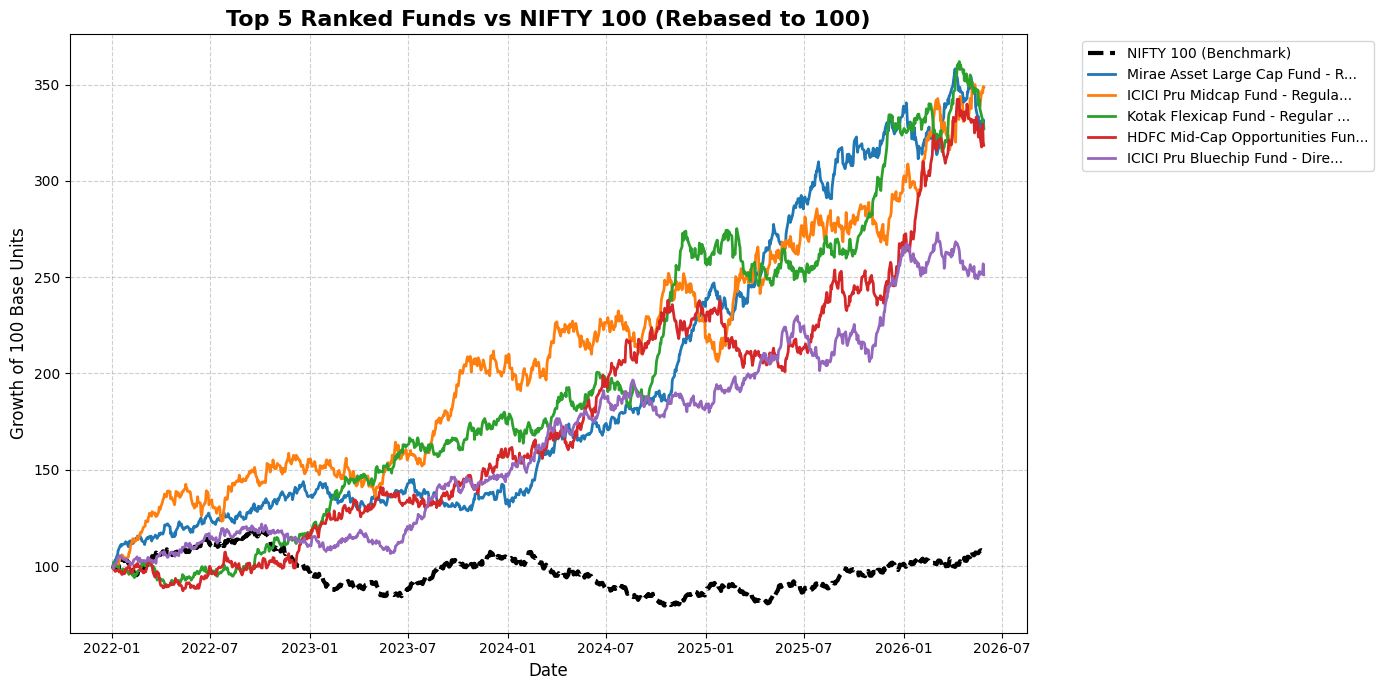

In [ ]:

top_5_amfi = df_master.head(5)['amfi_code'].tolist()
top_5_names = df_master.head(5)['scheme_name'].tolist()

plt.figure(figsize=(14, 7))


start_nifty = df_nifty100.iloc[0]['close_value']
plt.plot(df_nifty100['date'], (df_nifty100['close_value']/start_nifty)*100, 
         label='NIFTY 100 (Benchmark)', color='black', linewidth=3, linestyle='--')


for i, amfi in enumerate(top_5_amfi):
    fund_data = df_nav[df_nav['amfi_code'] == amfi].copy()
    start_nav = fund_data.iloc[0]['nav']
    plt.plot(fund_data['date'], (fund_data['nav']/start_nav)*100, label=top_5_names[i][:30]+"...", linewidth=2)

plt.title('Top 5 Ranked Funds vs NIFTY 100 (Rebased to 100)', fontsize=16, fontweight='bold')
plt.ylabel('Growth of 100 Base Units', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("benchmark_chart.png")
print("✅ Task 8: benchmark_chart.png generated!")
plt.show()